# HuggingFace Transformers

Research Transformer-based architecture with HuggingFace model for Time Series Forecasting.

# Notebook Setup

## Imports

In [8]:
# Import Standard Libraries
import pandas as pd
import numpy as np
from functools import lru_cache, partial
from datasets import load_dataset
import matplotlib.pyplot as plt

# Read Data

## Tourism Data

In [2]:
# Read time series data
tourism_data = load_dataset("monash_tsf", "tourism_monthly")

In [3]:
tourism_data # 3 datasets

DatasetDict({
    train: Dataset({
        features: ['start', 'target', 'feat_static_cat', 'feat_dynamic_real', 'item_id'],
        num_rows: 366
    })
    test: Dataset({
        features: ['start', 'target', 'feat_static_cat', 'feat_dynamic_real', 'item_id'],
        num_rows: 366
    })
    validation: Dataset({
        features: ['start', 'target', 'feat_static_cat', 'feat_dynamic_real', 'item_id'],
        num_rows: 366
    })
})

In [4]:
print(f'Start: {tourism_data['train'][0]['start'].strftime("%m/%d/%Y")}')
print(f'Time Steps: {len(tourism_data['train'][0]['target'])}')
print(f'First Time Step value: {tourism_data['train'][0]['target'][0]}')

Start: 01/01/1979
Time Steps: 139
First Time Step value: 1149.8699951171875


- `start` - Datetime start of the time series
- `target` - It contains the actual values of the time series (on a monthly basis)

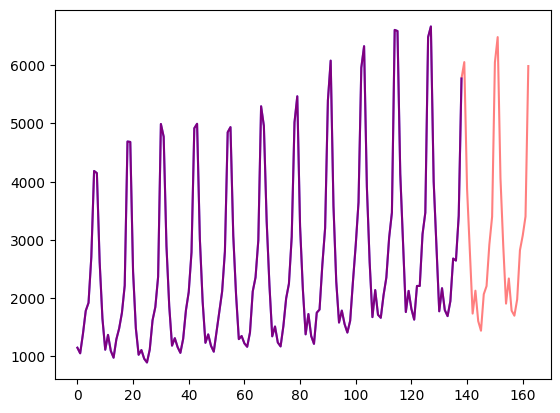

In [5]:
# Sample of data
figure, axes = plt.subplots()
axes.plot(tourism_data['train'][0]["target"], color="blue")
axes.plot(tourism_data['validation'][0]["target"], color="red", alpha=0.5)

plt.show()

# Data Preparation

## Tourism Data

In [6]:
# Train & Test split
tourism_data_train = tourism_data["train"]
tourism_data_test = tourism_data["test"]

In [9]:
# Transform the 'start' field into a Pandas Period
frequency = "1M"

@lru_cache(10_000) # Store results into the cache
def convert_to_pandas_period(date, freq):
    """Convert a date into the given frequency"""
    return pd.Period(date, freq)

def transform_start_field(batch, freq):
    """Transform the 'start' field """
    batch["start"] = [convert_to_pandas_period(date, freq) for date in batch["start"]]
    return batch

# Apply the transformation
# NOTE: Use partial to set the 'freq' argument
tourism_data_train.set_transform(partial(transform_start_field, freq=frequency))
tourism_data_test.set_transform(partial(transform_start_field, freq=frequency))

In [10]:
tourism_data_train[0]['start']

Period('1979-01', 'M')